In [21]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 100)
def read_outputs(file_path):
    outputs = pd.read_json(file_path, lines=True)
    outputs = outputs.explode('generations',ignore_index=True)
    # outputs['generations'] = outputs['generations'].apply(lambda x: [x])
    outputs['prompt']=outputs['prompt'].apply(lambda x: x['text'])
    
    outputs['text']=outputs['generations'].apply(lambda x: x['text'])
    
    gen_dict=outputs['generations'].values[0]
    
    for col in gen_dict.keys():
        outputs[col] = outputs['generations'].apply(lambda x: x.get(col,None))
        
    outputs.drop(columns=['generations'],inplace=True)
    return outputs

def ravel(unraveled_df):
    if 'tokens' in unraveled_df:
        unraveled_df['generations']= unraveled_df.apply(lambda x: [{'text': x['text'],
                                                               'tokens': x['tokens']}],axis=1)
    else:
        unraveled_df['generations']= unraveled_df.apply(lambda x: [{'text': x['text']}],axis=1)
    return_df = unraveled_df.groupby('prompt')['generations'].sum([]).reset_index()
    return_df['prompt'] = return_df['prompt'].apply(lambda x: {'text':x})
        
    return return_df

In [29]:
## 파일들을 읽는다.
gemma_gen = read_outputs('new_module/data/logical-consistency/gemma/r2-test_500_gemma-2-2b-it_49578.jsonl')
llama_gen = read_outputs('new_module/data/logical-consistency/llama/r2-test_500_Llama-3.1-8B-Instruct_49578.jsonl')
phi_gen = read_outputs('new_module/data/logical-consistency/phi/r2-test_500_Phi-3.5-mini-instruct_49611.jsonl')

## 생성문이 어떻게 생겨먹었는지 확인한다.


In [ ]:
## phi는 사족을 많이 붙인다. 처리.
def clean_text(x):
    x=x.replace("Hypothesis:", "")
    x=x.replace("hypothesis", "")
    x=x.replace("(Entailment)", "")
    x=x.replace("Entailment:", "")
    x=x.replace("Entailment :", "")
    x=x.replace("entailment:", "")
    x=x.split('\n\n')[0]
    return x

phi_gen['text_clean']=phi_gen['text'].apply(lambda x: clean_text(x))

In [ ]:
## 꽤 괜찮아서 이대로 저장
phi_gen = phi_gen.drop(columns=['text'])
phi_gen = phi_gen.rename(columns={'text_clean':'text'})
phi_gen_save = ravel(phi_gen)
phi_gen_save.to_json('new_module/data/logical-consistency/phi/r2-test_500_Phi-3.5-mini-instruct_49611_clean.jsonl',orient='records',lines=True)

In [33]:
gemma_gen['num_words'] = gemma_gen['text'].apply(lambda x: len(x.split()))
llama_gen['num_words'] = llama_gen['text'].apply(lambda x: len(x.split()))
phi_gen['num_words'] = phi_gen['text'].apply(lambda x: len(x.split()))

In [34]:
gemma_gen['num_words'].describe()

count    5000.00000
mean       11.62680
std         4.25365
min         3.00000
25%         9.00000
50%        11.00000
75%        14.00000
max        38.00000
Name: num_words, dtype: float64

In [35]:
llama_gen['num_words'].describe()

count    5000.000000
mean       11.832400
std         4.301861
min         4.000000
25%         9.000000
50%        11.000000
75%        14.000000
max        36.000000
Name: num_words, dtype: float64

In [36]:
phi_gen['num_words'].describe()

count    5000.000000
mean       27.223400
std         5.386659
min         8.000000
25%        24.000000
50%        28.000000
75%        31.000000
max        42.000000
Name: num_words, dtype: float64

In [19]:
gpt_gen = read_outputs('new_module/data/logical-consistency/anli-r2-test_prompt_4.jsonl')

In [21]:
gpt_gen['num_words'] = gpt_gen['text'].apply(lambda x: len(x.split()))

In [22]:
gpt_gen['num_words'].describe()

count    10000.000000
mean        13.926200
std          4.708436
min          4.000000
25%         11.000000
50%         13.000000
75%         16.000000
max         85.000000
Name: num_words, dtype: float64

<Axes: >

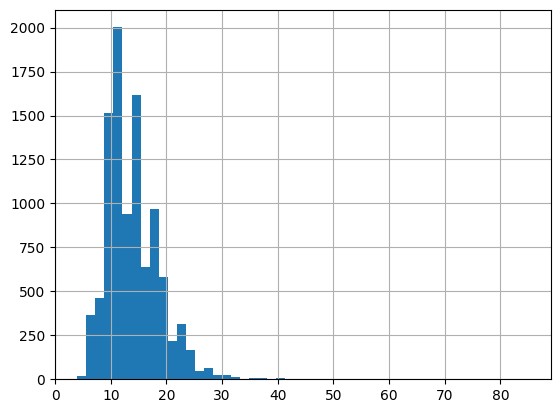

In [30]:
gpt_gen['num_words'].hist(bins=50)